<a href="https://colab.research.google.com/github/Grecia329/EcuacionesDiferencialesParciales-/blob/main/OC_S2_2026_Escalonada_General.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejemplo de distribucion escalonada con el Método de la Función Inversa

**Oliver Cuate**

*06 de marzo de 2026*

## Ejempo en general

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# tomemos una muestra de una distribución cualquiera
muestras = np.random.normal(5,2,1000)

# agrupemos en 5 intervalos
p, a = np.histogram(muestras, bins=5, density=True)

print(p, np.sum( p*(a[1:]-a[0:-1]) )  )
print(a)

[0.00978948 0.07138162 0.18803957 0.11625006 0.02243422] 0.9999999999999998
[-1.45229768  0.99931396  3.4509256   5.90253724  8.35414887 10.80576051]


In [ ]:
# Calculamos la acumulada
Fx = p*(a[1:]-a[0:-1])
for i in range(1,len(Fx)):
  Fx[i] += Fx[i-1]

Fx = np.insert(Fx,0,0)
print(Fx)

[0.    0.024 0.199 0.66  0.945 1.   ]


[-1.45229768  0.99931396  3.4509256   5.90253724  8.35414887 10.80576051]


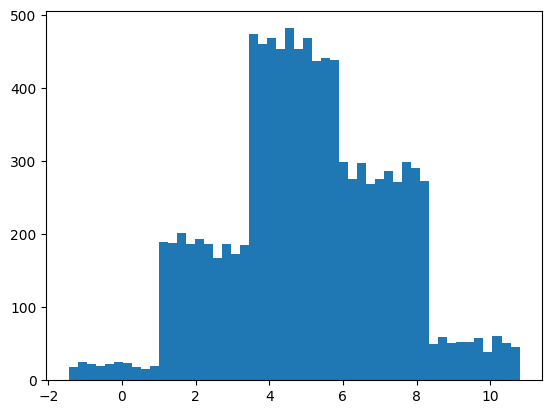

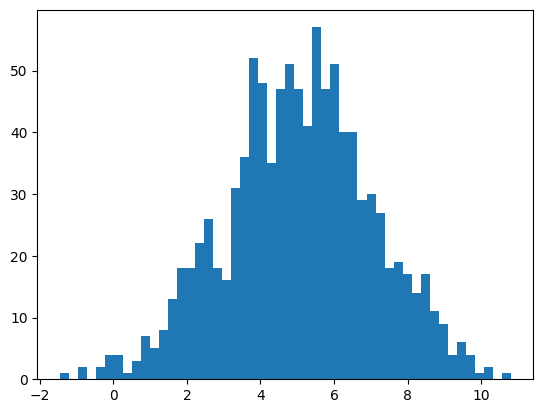

In [ ]:
def mti_escalonada(a,p,Fx,u):
  for (i,v) in enumerate(Fx):
    if v > u:
      return a[i-1] + (u-Fx[i-1])/p[i-1]

print(a)

n = 10000
verf = np.zeros(n)
for i in range(n):
  u = np.random.rand()
  verf[i] = mti_escalonada(a,p,Fx,u)

plt.hist(verf,bins=50)
plt.show()

print()

plt.hist(muestras,bins=50)
plt.show()

In [ ]:
import pandas as pd

datos = pd.read_csv('walmart.csv')
datos

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969
...,...,...,...,...,...,...,...,...,...,...
550063,1006033,P00372445,M,51-55,13,B,1,1,20,368
550064,1006035,P00375436,F,26-35,1,C,3,0,20,371
550065,1006036,P00375436,F,26-35,15,B,4+,1,20,137
550066,1006038,P00375436,F,55+,1,C,2,0,20,365


<Axes: ylabel='Count'>

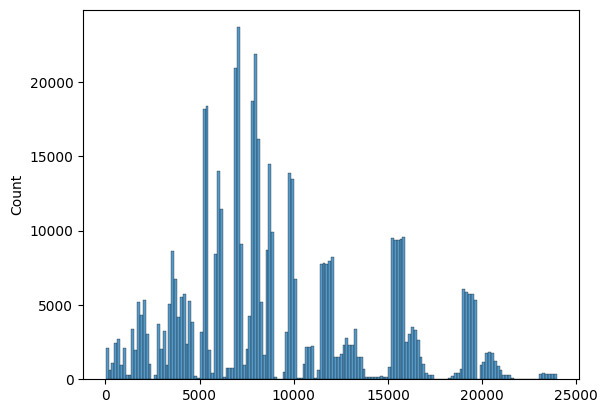

In [ ]:
import seaborn as sns
valores = datos['Purchase'].values

sns.histplot(valores)

In [ ]:
[p,a] = np.histogram(valores,bins=100,density=True)

In [ ]:
# Calculamos la acumulada
Fx = p*(a[1:]-a[0:-1])
for i in range(1,len(Fx)):
  Fx[i] += Fx[i-1]

Fx = np.insert(Fx,0,0)
print(Fx)

[0.         0.00463943 0.00765905 0.01230575 0.02059745 0.02221725
 0.02650581 0.03268141 0.04652697 0.06184872 0.06698081 0.0670099
 0.07430899 0.08155355 0.08584939 0.10647956 0.12423737 0.1391937
 0.15324651 0.16510141 0.17227506 0.17257503 0.20324396 0.24771119
 0.24901649 0.27728572 0.31067068 0.31185781 0.31401027 0.3453773
 0.41274533 0.41446148 0.42308587 0.46534974 0.52630766 0.53958601
 0.55382971 0.59541366 0.60177651 0.60190195 0.60348175 0.62823324
 0.66710116 0.67067708 0.67089523 0.67708538 0.68337551 0.68501167
 0.69801188 0.72046729 0.74307177 0.75956973 0.76390737 0.76911945
 0.77709847 0.78347404 0.79154941 0.79585615 0.79708509 0.79751958
 0.79793407 0.79841038 0.79886487 0.79922119 0.81978592 0.84659533
 0.87385741 0.89030265 0.89917428 0.90887127 0.91529775 0.91834646
 0.91927544 0.91990081 0.91990081 0.91990081 0.91993717 0.92025531
 0.92131882 0.92244232 0.93837671 0.95502738 0.97150898 0.97541031
 0.97872627 0.98353295 0.98875048 0.99203917 0.99406619 0.9949169

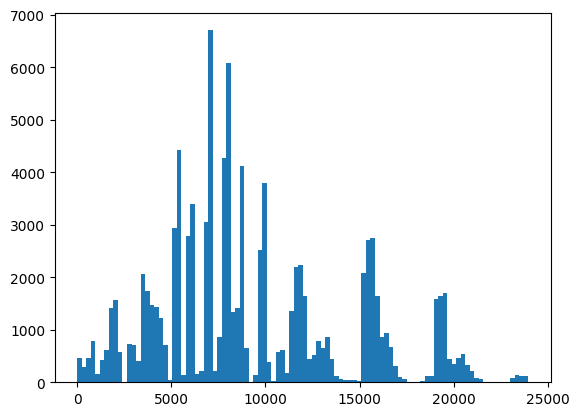

In [ ]:
n = 100000
verf = np.zeros(n)
for i in range(n):
  u = np.random.rand()
  verf[i] = mti_escalonada(a,p,Fx,u)

plt.hist(verf,bins=100)
plt.show()

In [ ]:
print(valores.shape)

(550068,)
